В цьому домашньому завданні ми реалізуємо логістичну регресію на `numpy`.
Ці завдання допоможуть вам ґрунтовно засвоїти основні концепції логістичної регресії та реалізувати їх на практиці 🔥

#### Завдання 1: Реалізація функції сигмоїди
1. З використанням `numpy` напишіть функцію `sigmoid(z)` для обчислення значення сигмоїди згідно з формулою:
   $$
   \sigma(z) = \frac{1}{1 + e^{-z}}
   $$
2. Використовуючи цю функцію, обчисліть значення сигмоїди для наступних даних: $ z = [-2, -1, 0, 1, 2] $. Виведіть результат обчислень.


In [1]:
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt

In [2]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

z = np.array([-2, -1, 0, 1, 2])
sigmoid_values = sigmoid(z)
print(sigmoid_values)

[0.11920292 0.26894142 0.5        0.73105858 0.88079708]


In [3]:
z_lin = np.linspace(-10, 10, 400)
sig = sigmoid(z_lin)

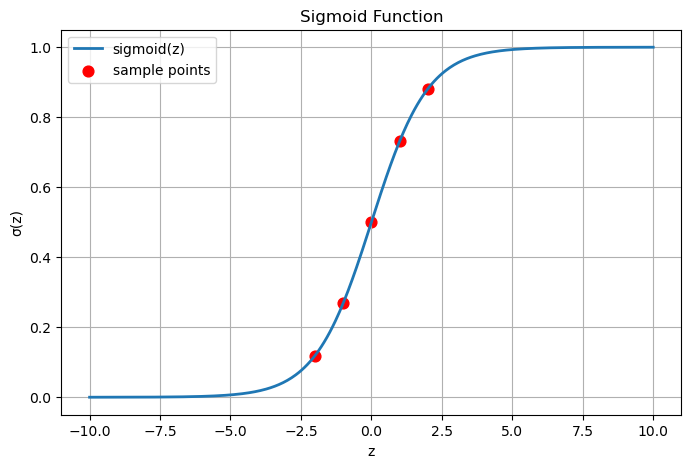

In [4]:
plt.figure(figsize=(8, 5))
plt.plot(z_lin, sig, label="sigmoid(z)", linewidth=2)
plt.scatter(z, sigmoid_values, color="red", s=60, label="sample points")

plt.title("Sigmoid Function")
plt.xlabel("z")
plt.ylabel("σ(z)")
plt.grid(True)
plt.legend()
plt.show()



#### Завдання 2: Реалізація функції гіпотези для логістичної регресії
1. Напишіть функцію `hypothesis(theta, X)`, яка обчислює гіпотезу для логістичної регресії, використовуючи функцію сигмоїди. Формула гіпотези:
   $$
   h_\theta(x) = \sigma(\theta^T x) = \frac{1}{1 + e^{-\theta^T x}}
   $$
2. Використайте функцію `hypothesis` для обчислення значень гіпотези для наступних даних:
   
   $\theta = [0.5, -0.5]$
   
   $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  Виведіть результат обчислень.


In [5]:
def hypothesis(theta, X):
    z = X @ theta
    return sigmoid(z)

In [6]:
theta = np.array([0.5, -0.5])

In [7]:
X = np.array([
    [1, 2],
    [1, -1],
    [1, 0],
    [1, 1]
])

In [8]:
hypothesis_values = hypothesis(theta, X)
print(hypothesis_values)

[0.37754067 0.73105858 0.62245933 0.5       ]


#### Завдання 3: Реалізація функції для підрахунку градієнтів фукнції втрат
1. Напишіть функцію `compute_gradient(theta, X, y)`, яка обчислює градієнти функції втрат для логістичної регресії. Формула для обчислення градієнта:
   $$
   \frac{\partial L(\theta)}{\partial \theta_j} = \frac{1}{m} \sum_{i=1}^{m} \left[ (h_\theta(x^{(i)}) - y^{(i)}) x_j^{(i)} \right]
   $$
2. Використайте функцію `compute_gradient` для обчислення градієнтів для наступних даних:

  $\theta = [0.5, -0.5]$

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Виведіть результат обчислень.

Векторизована формула:
$$
\nabla _{\theta }L(\theta )=\frac{1}{m}X^T(h-y)
$$

In [9]:
def compute_gradient(theta, X, y):
    m = len(y)
    h = hypothesis(theta, X)
    return (1/m) * (X.T @ (h - y))

In [10]:
y = np.array([1, 0, 1, 0])

In [11]:
compute_gradient_values = compute_gradient(theta, X, y)
print(compute_gradient_values)

[ 0.05776464 -0.36899431]



#### Завдання 4: Реалізація повного батч градієнтного спуску

**Задача:**
1. Напишіть функцію `full_batch_gradient_descent(X, y, lr=0.1, epochs=100)`, яка реалізує алгоритм Full градієнтного спуску для логістичної регресії. Використовуйте такі формули:
   - Гіпотеза: $ h_\theta(x) = \sigma(\theta^T x) $
   - Оновлення параметрів: $ \theta_j := \theta_j - \alpha \frac{\partial L(\theta)}{\partial \theta_j} $
2. Використайте функцію `full_batch_gradient_descent` для обчислення параметрів моделі на наступних даних:

  $X = \begin{bmatrix} 1 & 2 \\ 1 & -1 \\ 1 & 0 \\ 1 & 1 \end{bmatrix}$

  $y = [1, 0, 1, 0]$

  Увага! Матриця $X$ вже має стовпець одиниць і передбачається, що це. - стовпець для intercept - параметра зсуву.

  Виведіть результат обчислень.


In [12]:
def full_batch_gradient_descent(X, y, lr=0.1, epochs=100):
    # 1. Ініціалізуємо theta нулями правильної форми
    theta = np.zeros(X.shape[1])
    
    # 2. Запускаємо цикл градієнтного спуску
    for _ in range(epochs):
        grad = compute_gradient(theta, X, y)
        theta = theta - lr * grad
    
    # 3. Повертаємо навчені параметри
    return theta

In [13]:
theta_final = full_batch_gradient_descent(X, y)
print(theta_final)

[-0.2893693   0.77655125]


#### Завдання 5. Обчислення точності моделі

1. Напишіть функцію `predict_proba(theta, X)`, яка використовує знайдені параметри $\theta$ для обчислення ймовірностей належності поточного прикладу з даних до класу $y=1$ на основі значень $\sigma(\theta^T x)$.

2. Напишіть функцію `predict(theta, X, threshold=0.5)`, яка обчислює клас з передбаченої імовірності належності екземпляра до класу 1 з порогом 0.5. Тобто якщо ймовірність менше 0.5, то передбачаємо клас 0, інакше клас 1.

3. Напишіть функцію `accuracy(y_true, y_pred)`, яка обчислює точність моделі, визначивши частку правильно передбачених класів.

  Формула метрики Accuracy:
  $$
  \text{Accuracy} = \frac{\sum_{i=1}^{m} I(\hat{{y}^{(i)}} = y^{(i)})}{m}
  $$

  де $\hat{{y}^{(i)}}$ - передбачене значення класу, $I$ - індикаторна функція (яка дорівнює 1, якщо умова виконується, і 0 - якщо ні), $m$ - кількість прикладів.

4. Обчисліть з використанням даних в завданні 4 $X$, $y$ та обчислених коефіцієнтах $\theta$ та виведіть на екран:
  - передбачені моделлю імовірності належності кожного з екземплярів в матриці `X` до класу 1
  - класи кожного екземпляра з матриці `X`
  - точність моделі.

In [14]:
def predict_proba(theta, X):
    return sigmoid(X @ theta)

In [15]:
def predict(theta, X, threshold=0.5):
    probas = predict_proba(theta, X)
    return (probas >= threshold).astype(int)

In [16]:
def accuracy(y_true, y_pred):
    return np.mean(y_true == y_pred)

In [17]:
probas = predict_proba(theta_final, X)
print(probas)

[0.77966809 0.25617965 0.42815828 0.61944235]


[0.77966809 0.25617965 0.42815828 0.61944235]

In [18]:
preds = predict(theta_final, X)
print(preds)

[1 0 0 1]


In [19]:
acc = accuracy(y, preds)
print(acc)

0.5


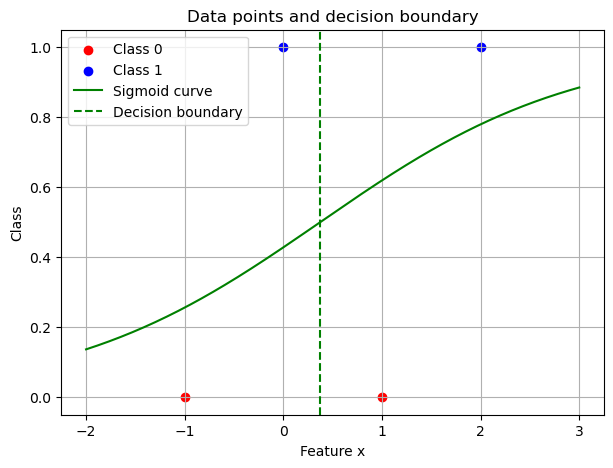

In [20]:
# Точки
x_vals = X[:, 1]  # друга колонка — справжній x
y_vals = y

# Створюємо діапазон x для плавної кривої
x_range = np.linspace(-2, 3, 300)

# Обчислюємо сигмоїду: σ(θ0 + θ1 * x)
z_theta_final = theta_final[0] + theta_final[1] * x_range
sigmoid_curve = sigmoid(z_theta_final)

# Побудова decision boundary:
# θ0 + θ1 * x = 0  →  x = -θ0 / θ1
boundary_x = -theta_final[0] / theta_final[1]

plt.figure(figsize=(7, 5))

# Малюємо точки
plt.scatter(x_vals[y==0], y_vals[y==0], color='red', label='Class 0')
plt.scatter(x_vals[y==1], y_vals[y==1], color='blue', label='Class 1')

# Малюємо сигмоїду
plt.plot(x_range, sigmoid_curve, color='green', label='Sigmoid curve')

# Малюємо decision boundary як вертикальну лінію
plt.axvline(boundary_x, color='green', linestyle='--', label='Decision boundary')

plt.xlabel("Feature x")
plt.ylabel("Class")
plt.title("Data points and decision boundary")
plt.legend()
plt.grid(True)
plt.show()

**Висновок**
У нашому X та y дані чергуються. Жодна пряма не може розділити ці точки.
Логістична регресія - лінійний класифікатор, тому вона неминуче робить 2 помилки з 4 → accuracy = 0.5.